<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Testing for Unphysical Precipitation Values in UKCP Local
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>In the set of extreme events extracted from UKCP Local (bias-corrected, 
  5km data), some events have maximum precipitation values which are 
  unphysical — i.e., higher than is physically plausible.</p>

  <p><strong>This script tests:</strong></p>
  <ul>
    <li>The number of events per catchment, per ensemble member with an unphysical value</li>
    <li>The number of pixels affected per event</li>
  </ul>

  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div>

</div>

In [32]:
import numpy as np
import pandas as pd
import re
import time
import gc
import os
import sys
import math
import glob
import datetime
import geopandas as gpd
from shapely.geometry import MultiPolygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import Counter

from functions import *
from functions_stage2 import (get_rainfall_cube_subsection,get_rainfall_cube_subsection_notbc, setup_worker_logger, 
                              find_max_precip_location_new, find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check, plot_n_peaks, get_exceedance_summary, plot_surrounding_ts, 
                              plot_surrounding_ts_new, find_problematic_catchment_em_combos, find_problematic_catchment_em_combos_complex)

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 

# ── Define which catchments to run ────────────────────────────────────────────────────────────────────
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Find catchment, ensemble member combinations with values >150mm/hr </h3>

  <p>For each catchment–ensemble member combination:</p>
  <ul>
    <li>Find the number of events exceeding the <strong>150mm/hr</strong> threshold</li>
    <li>Calculate this as a proportion of the total number of events</li>
  </ul>
    
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that for affected catchments the number of events affected are not insignificant: of the 66 instances of a catchment/ensemble member combination which appear in results_df ~50% have more than 10% of the events with unphysical values, and some have up to almost 50%.    
  </div>    

  <p>Also finds, for the highest peak value in each catchment:</p>
  <ul>
    <li>The number of timesteps which are unphysical (in any catchment cell) </li>
    <li>The number of cells which experience any unphysical values within 10 timesteps of the highest unphysical value </li>
    <li>The total number of cells in any cell, at any timestep (within 10 timesteps of the highest unphysical value) which are unphysical </li>     
      <li> The maximum number of cells experiencing an unphysical value concurrently </li>
      <li> The maximum number of timesteps for one cell which experience an unphysical value
  </ul>
<div style="background-color: white; border-left: 4px solid orange; 
padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that the unphysical values do not always occur in isolation. There are frequently either (i) other grid cells nearby affected, or (ii) other timesteps affected before or after.
   
  </div>   
</div>

In [35]:
results_df, problematic_catchment_names, problematic_catchment_nums = find_problematic_catchment_em_combos_complex(all_catchments, CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, RAINFALL_CSV_DIR)
results_df.sort_values(by='% Problematic', ascending = False)[:25]

,Catchment No.,Catchment Name,Ensemble Member,Highest Peak (mm),Events > 150mm,Total Events,% Problematic,Timesteps w/ any exceedance,Cells w/ any exceedance,"Total (t,cell) exceedances",Max cells in 1 timestep,Max timesteps for 1 cell
15,106,OuterHebrides,07,6779.93,108,221,48.9,1,8,8,8,1
62,96,Navergroup,07,7916.53,60,169,35.5,1,1,1,1,1
57,95,LaxfordGroup,07,7679.34,74,214,34.6,11,1,11,1,11
20,107,Orkneys,07,3003.31,39,127,30.7,1,1,1,1,1
23,3,ShinGroup,07,838.19,34,127,26.8,2,2,3,2,2
53,94,LochMareegroup,08,1196.80,62,263,23.6,2,3,4,2,2
52,94,LochMareegroup,07,4092.69,33,145,22.8,4,2,4,1,3
13,105,InnerHebrides,12,582.89,25,118,21.2,1,1,1,1,1
55,94,LochMareegroup,15,1136.14,26,134,19.4,1,2,2,2,1
9,105,InnerHebrides,07,3592.72,43,228,18.9,3,6,7,5,2


<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot location of catchments with problematic peaks </h3>

Plots a spatial plot showing affected catchments, coloured by how many EMs have problems (NB: not by the total number of events across ensemble members (maybe this'd be more useful)
</div>

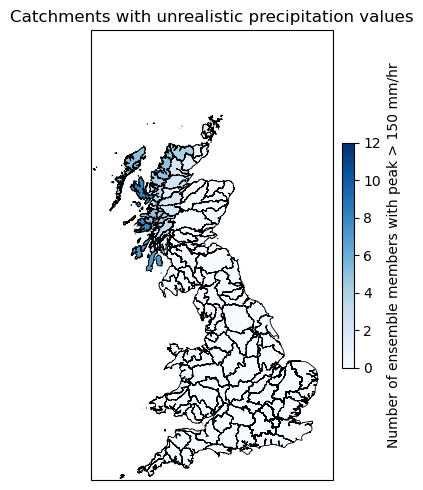

In [3]:
# Count how many ensemble members are problematic per catchment
ens_counts = Counter(problematic_catchment_nums)  # {catchment_num: count}

# Colourmap setup
max_count = len(ENSEMBLE_MEMBERS)
cmap      = cm.Blues
norm      = mcolors.Normalize(vmin=0, vmax=max_count)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': ccrs.OSGB()})

for catchment_num in CATCHMENTS['HA_NUM'].unique():
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    count          = ens_counts.get(catchment_num, 0)  # 0 if not problematic
    facecolor      = cmap(norm(count))
    ax.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(), 
                      facecolor=facecolor, edgecolor='black', linewidth=0.6)

# Add colourbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Number of ensemble members with peak > 150 mm/hr', 
             shrink=0.5, pad=0.02)

ax.set_title('Catchments with unrealistic precipitation values')
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h3 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 94 (Loch Maree Group) </h3>

Two test plots: 
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)  </div>    
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This suggests that often other unphysical values occur in the surrounding cells/timesteps to the peak. </div>    
   
**Additionally**: plot the same plots using data that hasn't been bias corrected:  

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.  </div>    

</div>

In [55]:
catchment_num = '94' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)
rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

LochMareegroup


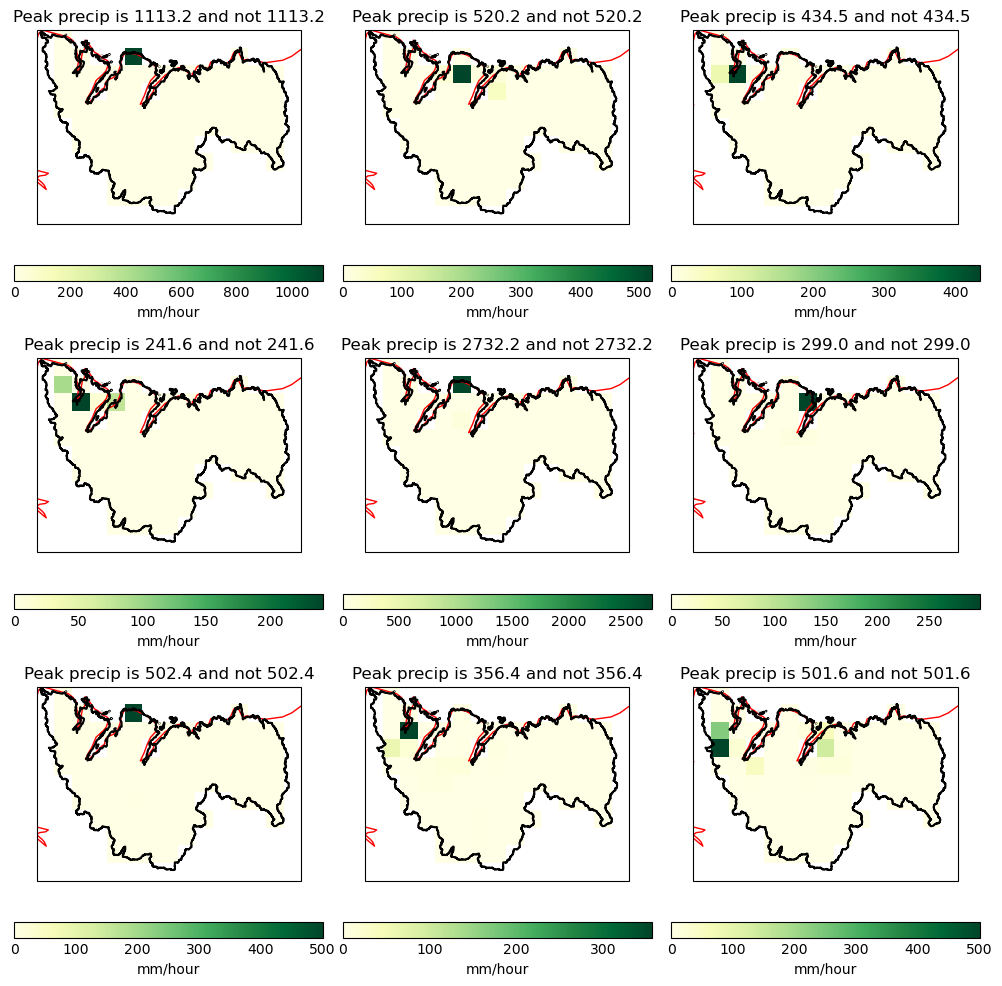

In [48]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=True)

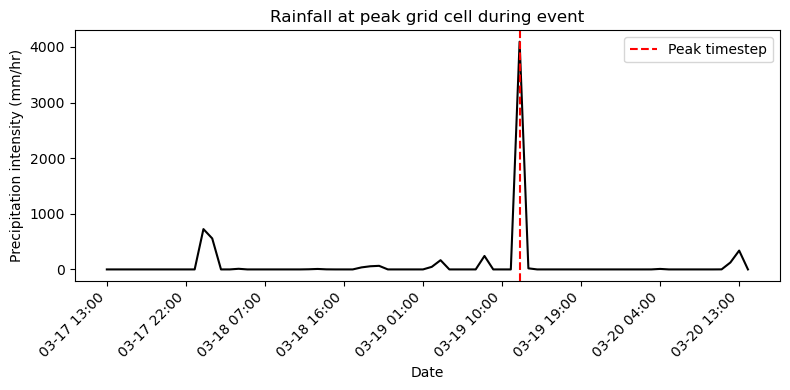


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 4
  Cells exceeding in ≥1 timestep : 2
  Total (t, cell) exceedances    : 4
  Max cells in a single timestep : 1
  Cells-per-timestep breakdown   : [0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0]


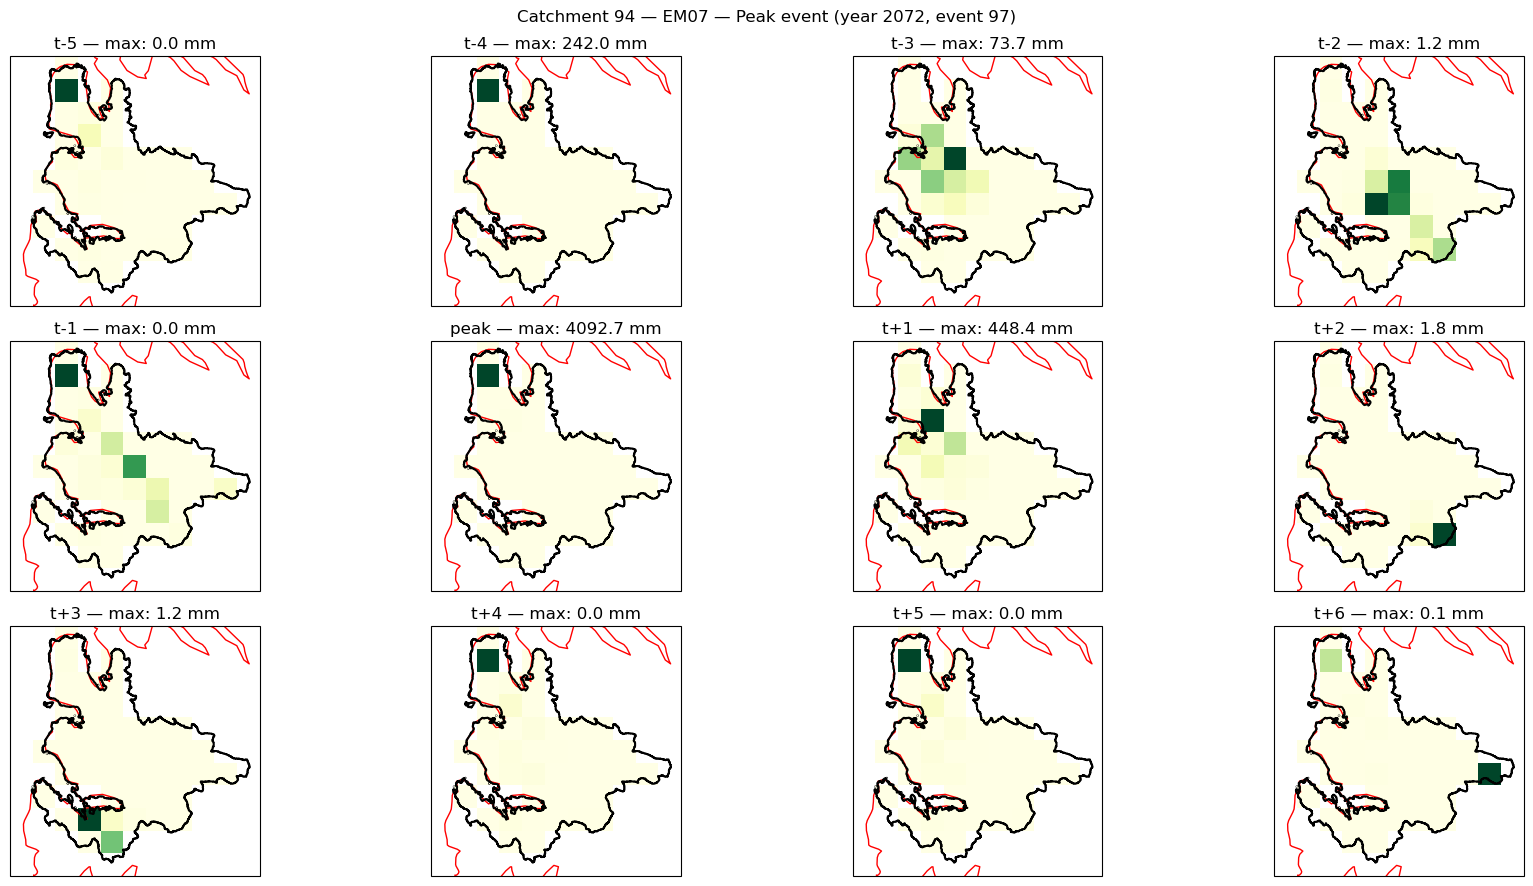

In [54]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

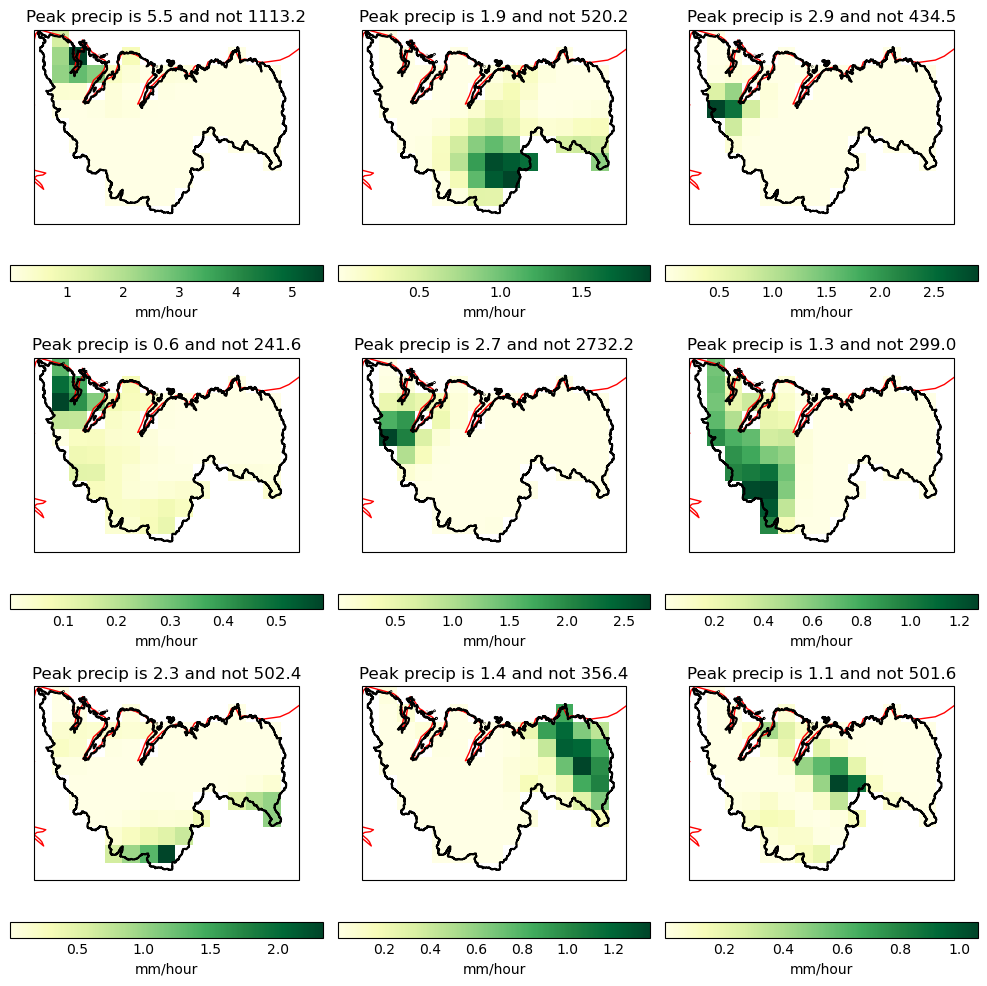

In [49]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h3 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 95 (Laxford Group) </h3>

Two test plots:  
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)  </div>    
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This suggests that often other unphysical values occur in the surrounding cells/timesteps to the peak. </div>    
   
**Additionally**: plot the same plots using data that hasn't been bias corrected:  

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.  </div>    

</div>

In [22]:
catchment_num = '95' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)

rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

LaxfordGroup


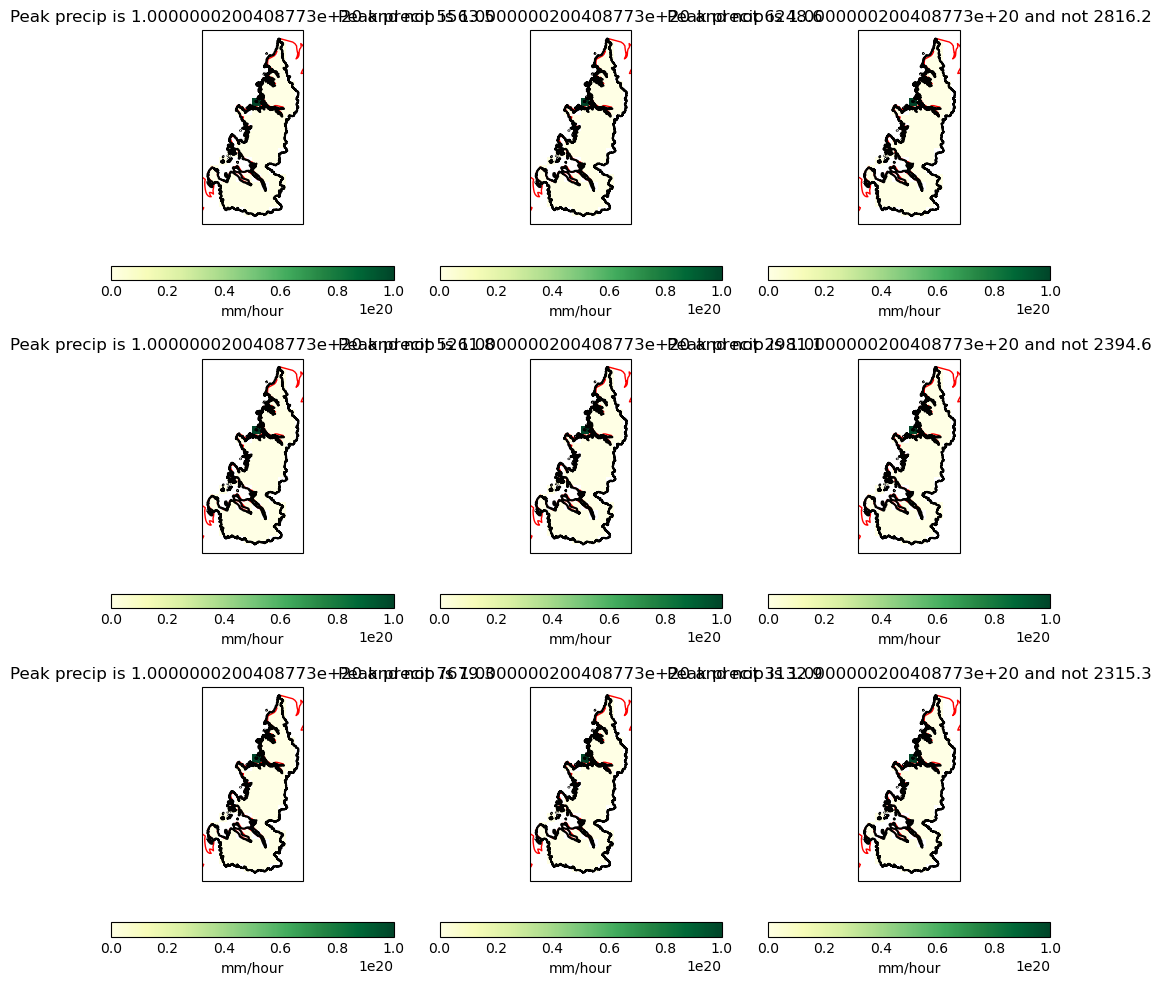

In [24]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, bc=True)

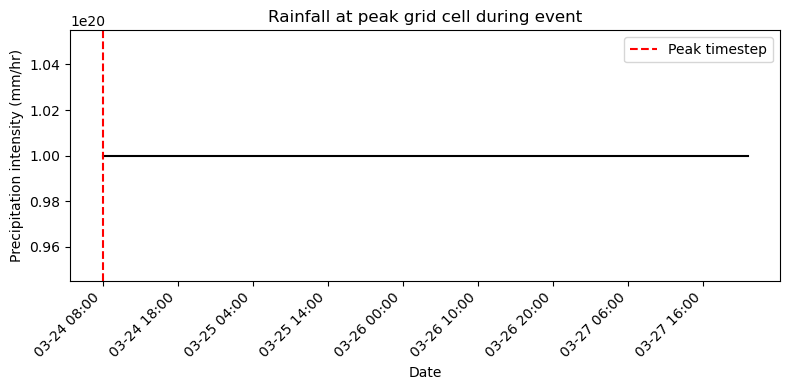


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 11
  Cells exceeding in ≥1 timestep : 1
  Total (t, cell) exceedances    : 11
  Max cells in a single timestep : 1
  Cells-per-timestep breakdown   : [1 1 1 1 1 1 1 1 1 1 1]


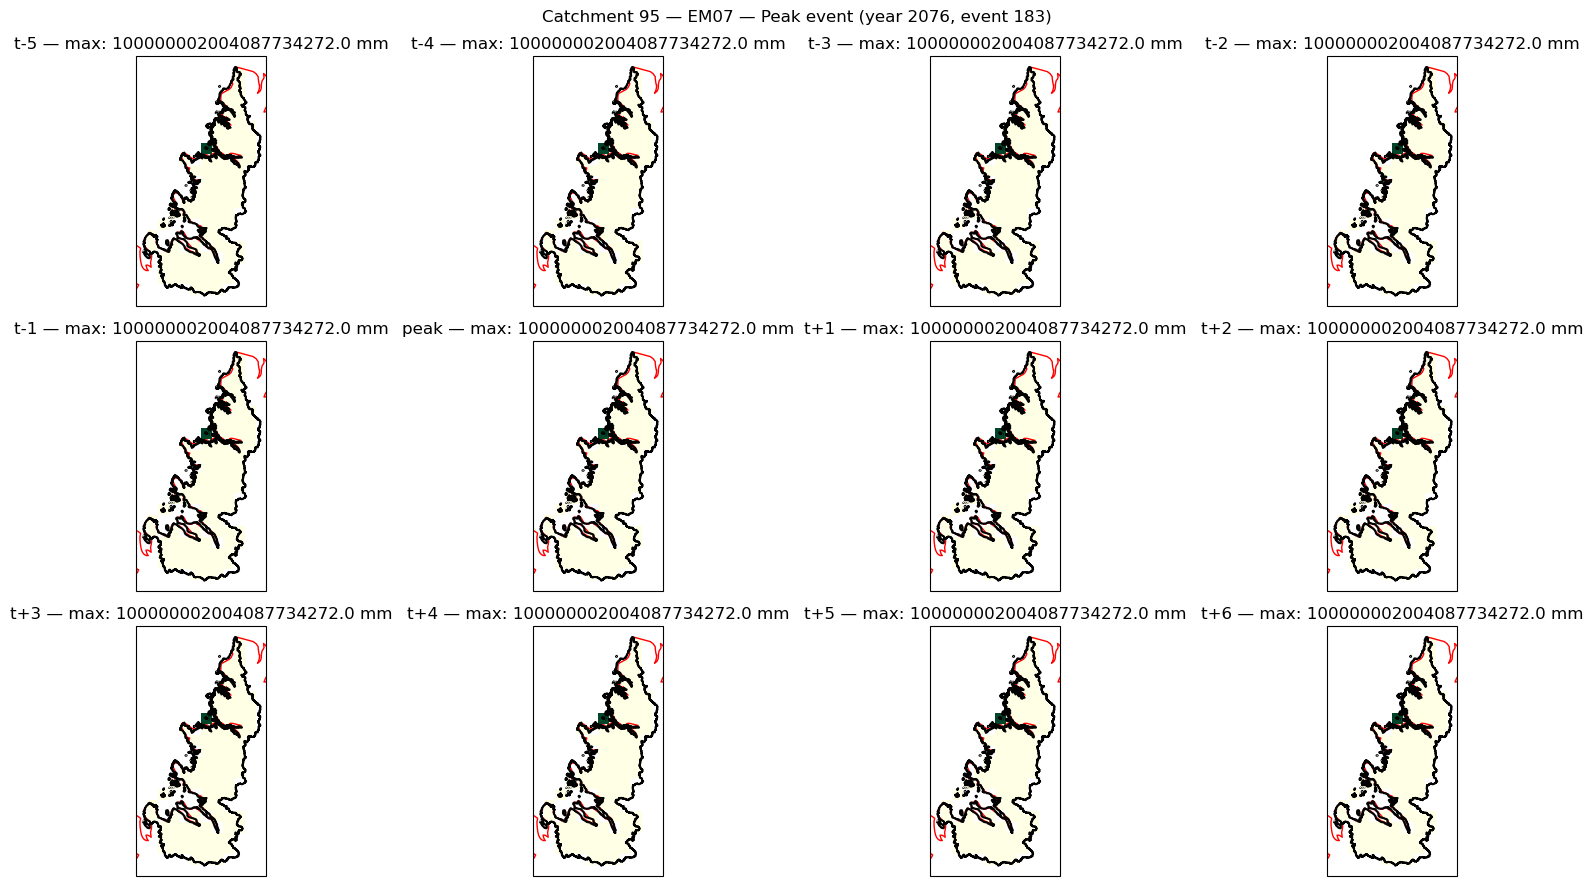

In [23]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

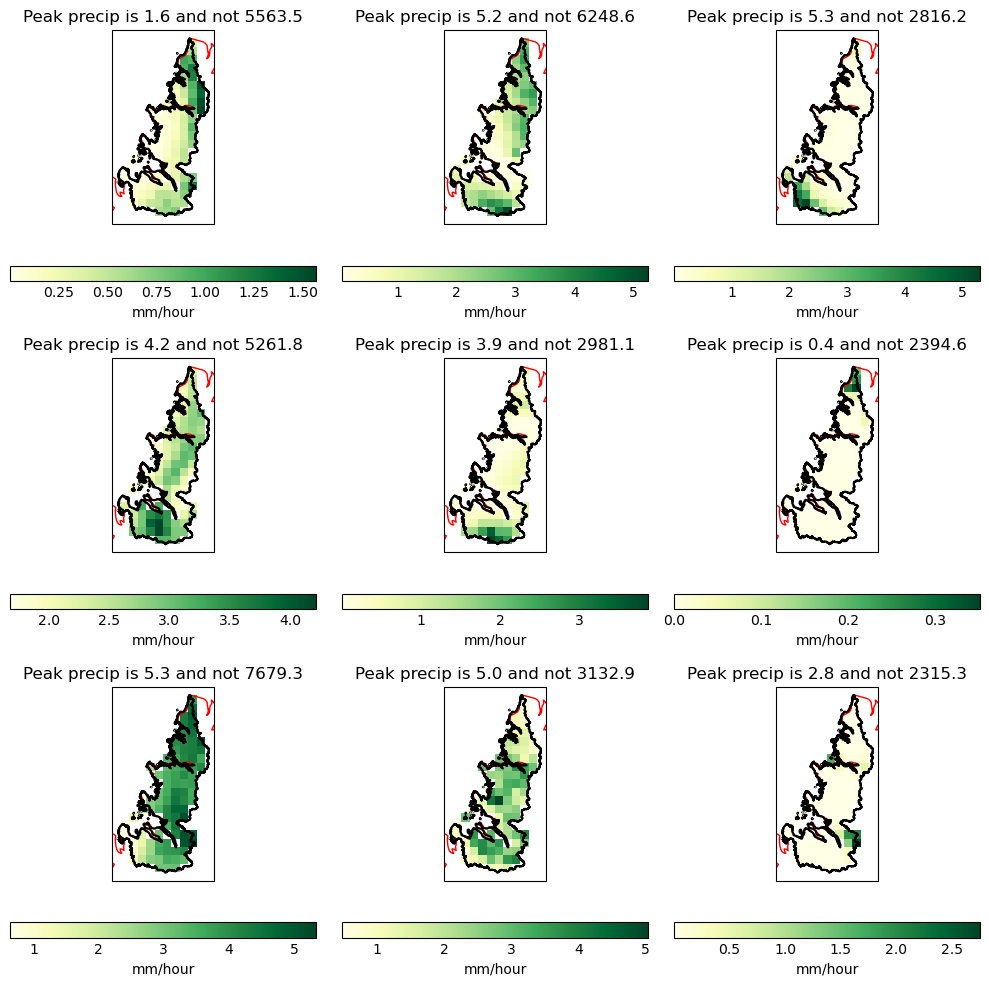

In [25]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)